# Bellasio2019

[https://doi.org/10.1007/s11120-018-0601-1](https://doi.org/10.1007/s11120-018-0601-1)

In [1]:
from mxlmodels import get_bellasio_2019

from mxlpy import Simulator, cartesian_product, scan, make_protocol
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import string
import copy

# Figure 3

In [2]:
fig3_m = get_bellasio_2019()

ppfd_list = [50, 75, 100, 150, 200, 500, 1000, 1500]
ca_list = [400, 300, 200, 120, 100, 80, 60, 40, 400, 400, 400, 400, 500, 650, 850, 1050, 1300]
p_O2_list = [21_0000, 2_0000]

fig3_m.update_parameters({
    "Ca": 400,
    "PPFD": 1500,
})

parameters_pfd = cartesian_product({
    "PPFD": ppfd_list,
    "p_o2": p_O2_list
})

parameters_ca = cartesian_product({
    "Ca": ca_list,
    "p_o2": p_O2_list
})

fig3_res_pfd = scan.time_course(
    model=fig3_m,
    to_scan=parameters_pfd,
    time_points=np.linspace(0, 1800, 1000)
)

fig3_res_pfd = fig3_res_pfd.combined
fig3_res_pfd = fig3_res_pfd.reset_index().groupby("n").last().drop(columns=["time"])
fig3_res_pfd = pd.concat([fig3_res_pfd, parameters_pfd], axis=1)
fig3_res_pfd = fig3_res_pfd.set_index(["PPFD", "p_o2"])

fig3_res_ca = scan.time_course(
    model=fig3_m,
    to_scan=parameters_ca,
    time_points=np.linspace(0, 1800, 1000)
)

fig3_res_ca = fig3_res_ca.combined
fig3_res_ca = fig3_res_ca.reset_index().groupby("n").last().drop(columns=["time"])
fig3_res_ca = pd.concat([fig3_res_ca, parameters_ca], axis=1)
fig3_res_ca["Ci_init"] = fig3_res_ca["Ca"] * 0.65
fig3_res_ca = fig3_res_ca.set_index(["Ca", "p_o2"])

100%|██████████| 34/34 [00:06<00:00,  5.54it/s]


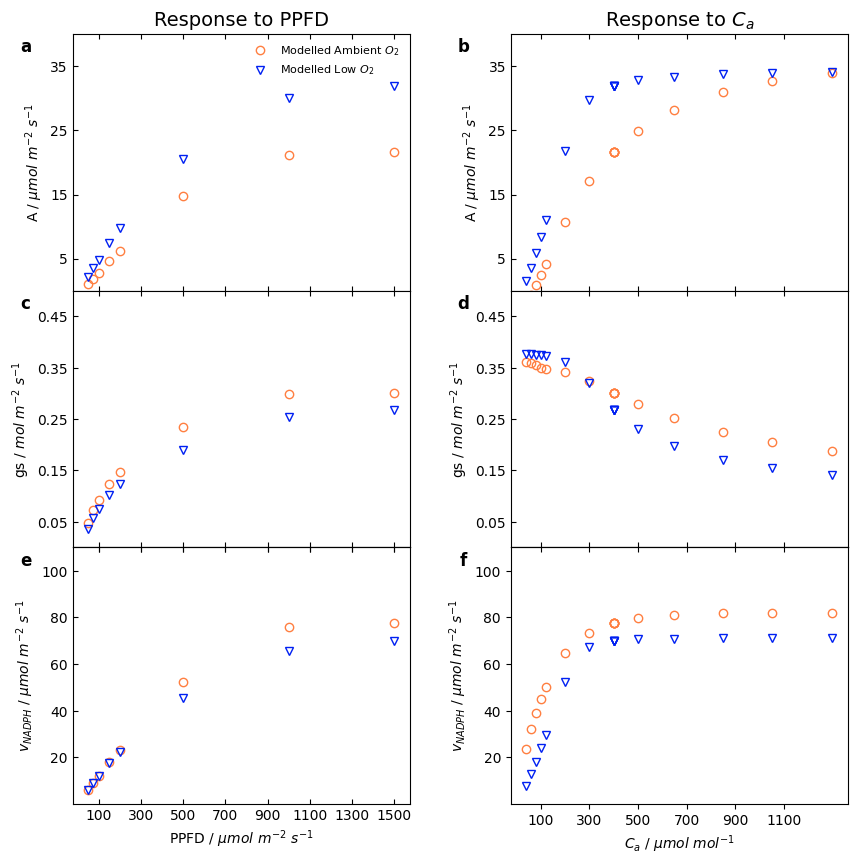

In [3]:
fig3, axs = plt.subplots(nrows=3, ncols=2, figsize=(10,10))

pO2_styles = {
    "color": {
        "210000": "#ff7f40",
        "20000": "#0020f2"
    },
    "marker": {
        "210000": "o",
        "20000": "v"
    }
}

for pO2 in p_O2_list:
    res_pfd = fig3_res_pfd.xs(pO2, axis=0, level=1, drop_level=True)
    res_ca = fig3_res_ca.xs(pO2, axis=0, level=1, drop_level=True)
    
    if pO2 == 210000:
        label = "Modelled Ambient $O_2$"
    else:
        label = "Modelled Low $O_2$"
    
    for i, res in enumerate([res_pfd, res_ca]):
        axs[0, i].plot(res["A"] * 1000, color=pO2_styles["color"][str(pO2)], marker=pO2_styles["marker"][str(pO2)], ls="None", markerfacecolor="none", label=label)
        axs[1, i].plot(res["gs"], color=pO2_styles["color"][str(pO2)], marker=pO2_styles["marker"][str(pO2)], ls="None", markerfacecolor="none")
        axs[2, i].plot(res["v_FNR"] * 1000, color=pO2_styles["color"][str(pO2)], marker=pO2_styles["marker"][str(pO2)], ls="None", markerfacecolor="none")

# Figure stylings

# Subplot titles
for i, ax in enumerate(axs.flat):
    ax.text(-0.14, 0.95, string.ascii_lowercase[i], transform=ax.transAxes, fontsize=12, fontweight="bold", va="center", ha="center")
    
for i, ax in enumerate(axs[0, :]):
    if i == 0:
        ax.set_title("Response to PPFD", fontsize=14)
    else:
        ax.set_title("Response to $C_a$", fontsize=14)

axs[0, 0].legend(loc="best", fontsize=8, frameon=False)

#X-Axis
axs[2, 0].set_xlabel("PPFD / $\\mu mol\\ m^{-2}\\ s^{-1}$")
axs[2, 1].set_xlabel("$C_a$ / $\\mu mol\\ mol^{-1}$")

xticks_pfd = np.linspace(100, 1500, 8)
xticks_ci = np.linspace(100, 1100, 6)
for i, xticks in enumerate([xticks_pfd, xticks_ci]):
    for ax in axs.flat:
        ax.tick_params(
            axis="both",
            which="both",
            direction="in",
            top=True,
            bottom=True
        )
        

    for ax in axs[:, i]:
        ax.set_xticks(xticks)
    axs[2, i].tick_params(
            axis="both",
            which="both",
            direction="out",
            top=False,
            bottom=True
        )
    sec_ax = axs[2, i].secondary_xaxis("top")
    sec_ax.set_xticks(xticks)
    sec_ax.tick_params(
            axis="both",
            which="both",
            direction="in",
            labeltop=False,
        )

# Ylabels
for ax in axs[0, :]:
    ax.set_ylabel("A / $\\mu mol\\ m^{-2}\\ s^{-1}$")
    ax.set_ylim(0, 40)
    ax.set_yticks(np.linspace(5, 35, 4))
    
for ax in axs[1, :]:
    ax.set_ylabel("gs / $mol\\ m^{-2}\\ s^{-1}$")
    ax.set_ylim(0, 0.50)
    ax.set_yticks(np.linspace(0.05, 0.45, 5))
    
for ax in axs[2, :]:
    ax.set_ylabel("$v_{NADPH}$ / $\\mu mol\\ m^{-2}\\ s^{-1}$")
    ax.set_ylim(0, 110)
    ax.set_yticks(np.linspace(20, 100, 5))

plt.subplots_adjust(hspace=0, wspace=0.3)

## Figure 4

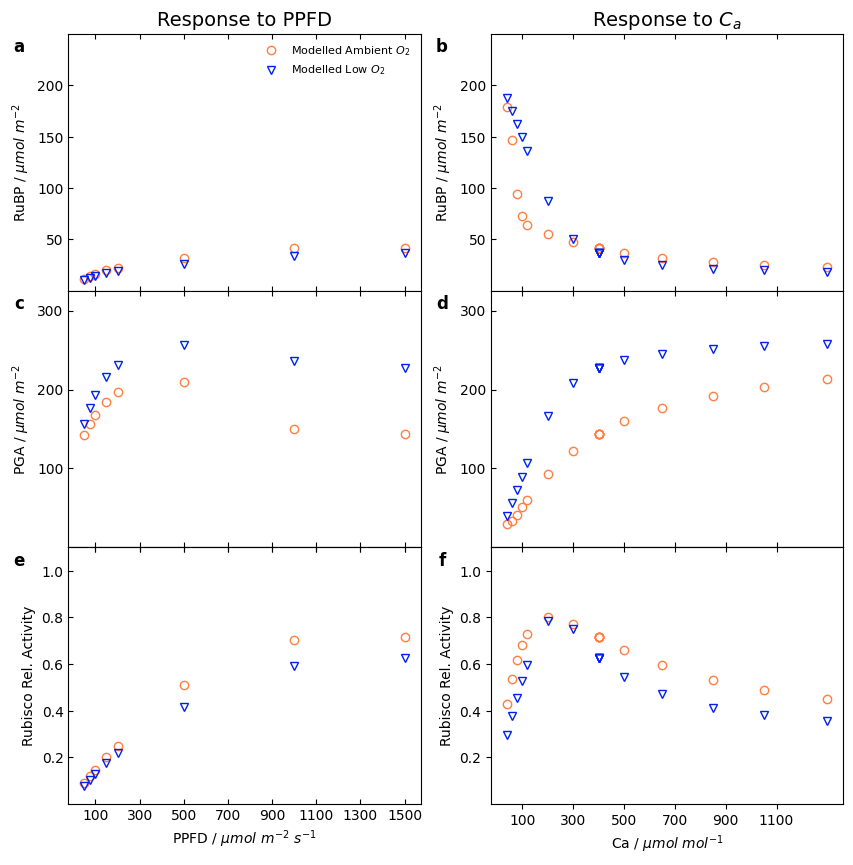

In [4]:
fig4, axs = plt.subplots(nrows=3, ncols=2, figsize=(10,10))

pO2_styles = {
    "color": {
        "210000": "#ff7f40",
        "20000": "#0020f2"
    },
    "marker": {
        "210000": "o",
        "20000": "v"
    }
}

for pO2 in p_O2_list:
    res_pfd = fig3_res_pfd.xs(pO2, axis=0, level=1, drop_level=True)
    res_ca = fig3_res_ca.xs(pO2, axis=0, level=1, drop_level=True)
    
    if pO2 == 210000:
        label = "Modelled Ambient $O_2$"
    else:
        label = "Modelled Low $O_2$"
    
    for i, res in enumerate([res_pfd, res_ca]):
        axs[0, i].plot(res["RUBP"] * get_bellasio_2019().get_parameter_values()["V_m"] * 1000, color=pO2_styles["color"][str(pO2)], marker=pO2_styles["marker"][str(pO2)], ls="None", markerfacecolor="none", label=label)
        axs[1, i].plot(res["PGA"] * get_bellasio_2019().get_parameter_values()["V_m"] * 1000, color=pO2_styles["color"][str(pO2)], marker=pO2_styles["marker"][str(pO2)], ls="None", markerfacecolor="none")
        axs[2, i].plot(res["Ract"] * res["f_rubp"], color=pO2_styles["color"][str(pO2)], marker=pO2_styles["marker"][str(pO2)], ls="None", markerfacecolor="none")

# Subplot titles
for i, ax in enumerate(axs.flat):
    ax.text(-0.14, 0.95, string.ascii_lowercase[i], transform=ax.transAxes, fontsize=12, fontweight="bold", va="center", ha="center")
    
for i, ax in enumerate(axs[0, :]):
    if i == 0:
        ax.set_title("Response to PPFD", fontsize=14)
    else:
        ax.set_title("Response to $C_a$", fontsize=14)
        
axs[0, 0].legend(loc="best", fontsize=8, frameon=False)

#X-Axis
axs[2, 0].set_xlabel("PPFD / $\\mu mol\\ m^{-2}\\ s^{-1}$")
axs[2, 1].set_xlabel("Ca / $\\mu mol\\ mol^{-1}$")

xticks_pfd = np.linspace(100, 1500, 8)
xticks_ci = np.linspace(100, 1100, 6)
for i, xticks in enumerate([xticks_pfd, xticks_ci]):
    for ax in axs.flat:
        ax.tick_params(
            axis="both",
            which="both",
            direction="in",
            top=True,
            bottom=True
        )
        

    for ax in axs[:, i]:
        ax.set_xticks(xticks)
    axs[2, i].tick_params(
            axis="both",
            which="both",
            direction="out",
            top=False,
            bottom=True
        )
    sec_ax = axs[2, i].secondary_xaxis("top")
    sec_ax.set_xticks(xticks)
    sec_ax.tick_params(
            axis="both",
            which="both",
            direction="in",
            labeltop=False,
        )

# Y-Axis
for ax in axs[0, :]:
    ax.set_ylabel("RuBP / $\\mu mol\\ m^{-2}$")
    ax.set_ylim(0, 250)
    ax.set_yticks(np.linspace(50, 200, 4))
    
for ax in axs[1, :]:
    ax.set_ylabel("PGA / $\\mu mol\\ m^{-2}$")
    ax.set_ylim(0, 325)
    ax.set_yticks(np.linspace(100, 300, 3))
    
for ax in axs[2, :]:
    ax.set_ylabel("Rubisco Rel. Activity")
    ax.set_ylim(0, 1.1)
    ax.set_yticks(np.linspace(0.2, 1.0, 5))

plt.subplots_adjust(hspace=0)

## Figure 5

In [5]:
fig5_m = get_bellasio_2019()
fig5_m.update_parameters({
    "Ca": 350,
    "vmax_v_RuBisCO_c": 0.18,
    "chi_beta": 0.8,
    "tau0": -0.12,
    "Ki": 3600,
    "Kd": 1200,
})

acc_duration = 400

fig5_res = {}

for acc_pfd, sim_pfd in [(50, 1500), (1500, 50)]:
    s = Simulator(fig5_m)
    
    s.simulate_protocol(
        protocol=make_protocol([
            (acc_duration, {"PPFD": acc_pfd}),
            (1800, {"PPFD": sim_pfd})
        ]),
        time_points_per_step=1000
    )
    
    res = s.get_result().unwrap_or_err().get_combined()
    res.index = res.index - acc_duration
    
    fig5_res[str(sim_pfd)] = res

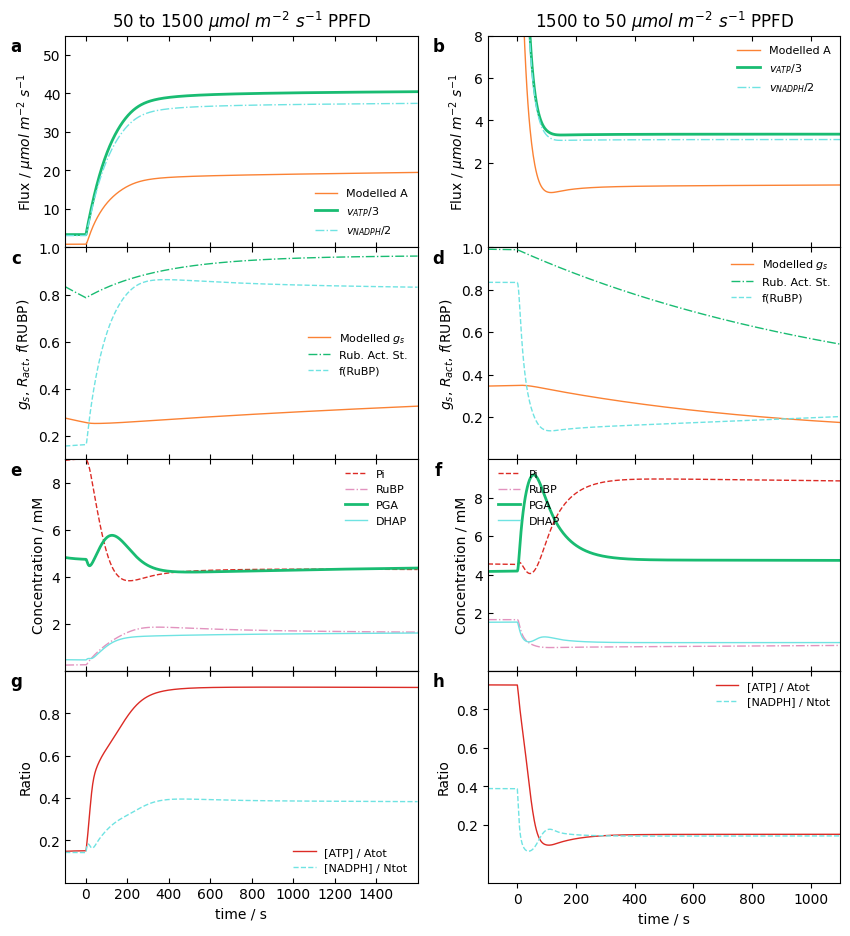

In [6]:
fig5, axs = plt.subplots(nrows=4, ncols=2, figsize=(10, 11))

orange = "#fb8234"
green = "#19bc72"
blue = "#6fe3e2"
red = "#dc2b25"
pink = "#e293bf"

style_dict = {
    "A": {"color": orange, "linestyle": "solid", "lw": 1},
    "v_ATP": {"color": green, "linestyle": "solid", "lw": 2},
    "v_NADPH": {"color": blue, "linestyle": "dashdot", "lw": 1},
    "gs": {"color": orange, "ls": "solid", "lw": 1},
    "Ract": {"color": green, "ls": "dashdot", "lw": 1},
    "f(rubp)": {"color": blue, "ls": "dashed", "lw": 1},
    "Pi": {"color": red, "ls": "dashed", "lw": 1},
    "RuBP": {"color": pink, "ls": "dashdot", "lw": 1},
    "PGA": {"color": green, "ls": "solid", "lw": 2},
    "DHAP": {"color": blue, "ls": "solid", "lw": 1},
    "ATP/Atot": {"color": red, "ls": "solid", "lw": 1},
    "NADPH/Ntot": {"color": blue, "ls": "dashed", "lw": 1}
}

for i, (sim_pfd, df) in enumerate(fig5_res.items()):
    # Row 0: A, v_ATP / 3, v_NADPH / 2
    axs[0, i].plot(df["A"] * 1000, **style_dict["A"], label="Modelled A")
    axs[0, i].plot(df["v_ATPsynth"] / 3 * 1000, **style_dict["v_ATP"], label="$v_{ATP} / 3$")
    axs[0, i].plot(df["v_FNR"] / 2 * 1000, **style_dict["v_NADPH"], label="$v_{NADPH} / 2$")
    # Row 1: gs, Ract, f(rubp)
    axs[1, i].plot(df["gs"], **style_dict["gs"], label="Modelled $g_s$")
    axs[1, i].plot(df["Ract"], **style_dict["Ract"], label="Rub. Act. St.")
    axs[1, i].plot(df["f_rubp"], **style_dict["f(rubp)"], label="f(RuBP)")
    # Row 2: Pi, RuBP, PGA, DHAP
    axs[2, i].plot(df["Pi_st"], **style_dict["Pi"], label="Pi")
    axs[2, i].plot(df["RUBP"], **style_dict["RuBP"], label="RuBP")
    axs[2, i].plot(df["PGA"], **style_dict["PGA"], label="PGA")
    axs[2, i].plot(df["DHAP"], **style_dict["DHAP"], label="DHAP")
    # Row 3: ATP / Atot, NADPH / Ntot
    axs[3, i].plot(df["ATP_st"] / get_bellasio_2019().get_parameter_values()["AP_tot"], **style_dict["ATP/Atot"], label="[ATP] / Atot")
    axs[3, i].plot(df["NADPH_st"] / get_bellasio_2019().get_parameter_values()["NADP_tot"], **style_dict["NADPH/Ntot"], label="[NADPH] / Ntot")
    

# Figure stylings

# Subplot titles
for i, ax in enumerate(axs.flat):
    ax.text(-0.14, 0.95, string.ascii_lowercase[i], transform=ax.transAxes, fontsize=12, fontweight="bold", va="center", ha="center")
    ax.legend(loc="best", fontsize=8, frameon=False)

#X-Axis
for ax in axs[-1, :]:
    ax.set_xlabel("time / s")

xticks_left = np.linspace(0, 1400, 8)
xticks_right = np.linspace(0, 1000, 6)
for i, xticks in enumerate([xticks_left, xticks_right]):
    for ax in axs.flat:
        ax.tick_params(
            axis="both",
            which="both",
            direction="in",
            top=True,
            bottom=True
        )
        

    for ax in axs[:, i]:
        ax.set_xticks(xticks)
        if i==0:
            ax.set_xlim(-100, 1600)
        else:
            ax.set_xlim(-100, 1100)
    axs[-1, i].tick_params(
            axis="both",
            which="both",
            direction="out",
            top=False,
            bottom=True
        )
    sec_ax = axs[-1, i].secondary_xaxis("top")
    sec_ax.set_xticks(xticks)
    sec_ax.tick_params(
            axis="both",
            which="both",
            direction="in",
            labeltop=False,
        )

# Y-Axis
for i, ax in enumerate(axs[0, :]):
    ax.set_ylabel("Flux / $\\mu mol\\ m^{-2}\\ s^{-1}$")
    if i==0:
        ax.set_ylim(0, 55)
        ax.set_yticks(np.linspace(10, 50, 5))
        ax.set_title("50 to 1500 $\\mu mol\\ m^{-2}\\ s^{-1}$ PPFD")
    else:
        ax.set_ylim(-2, 8)
        ax.set_yticks(np.linspace(2, 8, 4))
        ax.set_title("1500 to 50 $\\mu mol\\ m^{-2}\\ s^{-1}$ PPFD")
    
for i, ax in enumerate(axs[1, :]):
    ax.set_ylabel("$g_s$, $R_{act}$, $f$(RUBP)")
    if i==0:
        ax.set_ylim(0.1, 1.0)
        
    else:
        ax.set_ylim(0, 1.0)
    ax.set_yticks(np.linspace(0.2, 1.0, 5))
    
for i, ax in enumerate(axs[2, :]):
    ax.set_ylabel("Concentration / mM")
    if i==0:
        ax.set_ylim(0, 9)
        ax.set_yticks(np.linspace(2, 8, 4))
    else:
        ax.set_ylim(-1, 10)
        ax.set_yticks(np.linspace(2, 8, 4))

for i, ax in enumerate(axs[3, :]):
    ax.set_ylabel("Ratio")
    if i==0:
        ax.set_ylim(0, 1)
        ax.set_yticks(np.linspace(0.2, 0.8, 4))
    else:
        ax.set_ylim(-0.1, 1)
        ax.set_yticks(np.linspace(0.2, 0.8, 4))

plt.subplots_adjust(hspace=0)

## Figure 6

In [7]:
fig6_m = get_bellasio_2019()

fig6_m.update_parameters({
    "PPFD": 1500,
    "vmax_v_RuBisCO_c": 0.18,
    "chi_beta": 0.8,
    "tau0": -0.12,
    "Ki": 3600,
    "Kd": 1200,
})

acc_duration = 400

fig6_res = {}

for acc_ca, sim_ca in [(350, 1500), (1500, 350)]:
    s = Simulator(fig6_m)
    
    s.simulate_protocol(
        protocol=make_protocol([
            (acc_duration, {"Ca": acc_ca}),
            (500, {"Ca": sim_ca})
        ]),
        time_points_per_step=1000
    )
    
    res = s.get_result().unwrap_or_err().get_combined()
    res.index = res.index - acc_duration
    
    fig6_res[str(sim_ca)] = res

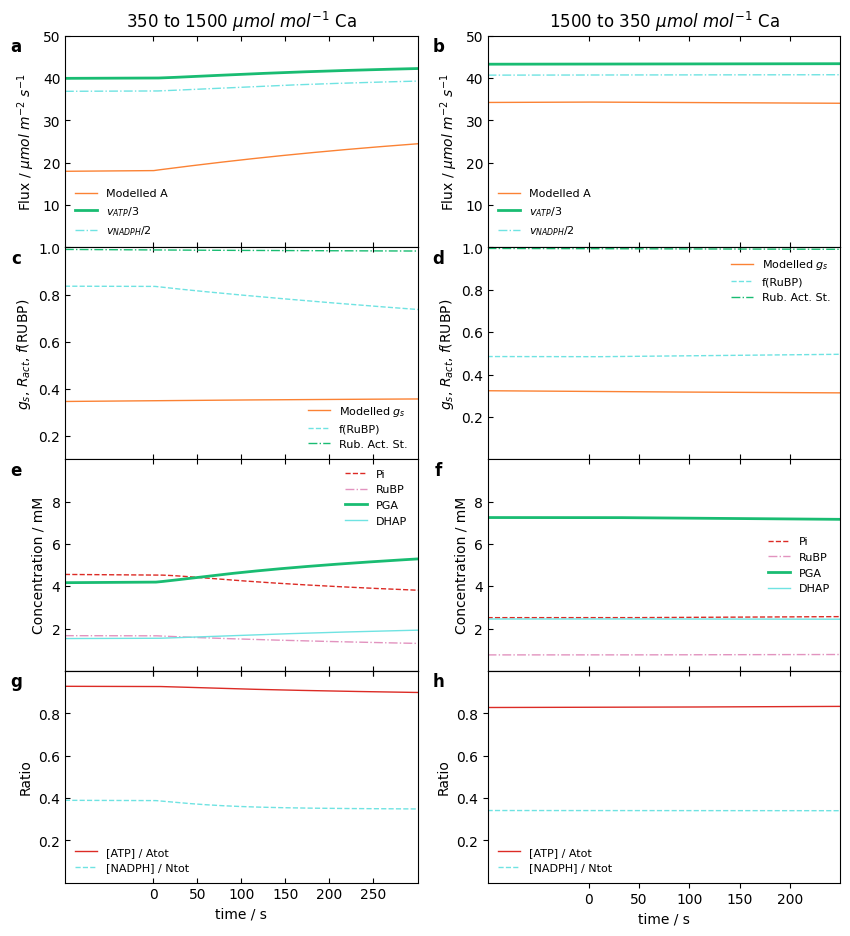

In [8]:
fig6, axs = plt.subplots(nrows=4, ncols=2, figsize=(10, 11))

orange = "#fb8234"
green = "#19bc72"
blue = "#6fe3e2"
red = "#dc2b25"
pink = "#e293bf"

style_dict = {
    "A": {"color": orange, "linestyle": "solid", "lw": 1},
    "v_ATP": {"color": green, "linestyle": "solid", "lw": 2},
    "v_NADPH": {"color": blue, "linestyle": "dashdot", "lw": 1},
    "gs": {"color": orange, "ls": "solid", "lw": 1},
    "Ract": {"color": green, "ls": "dashdot", "lw": 1},
    "f(rubp)": {"color": blue, "ls": "dashed", "lw": 1},
    "Pi": {"color": red, "ls": "dashed", "lw": 1},
    "RuBP": {"color": pink, "ls": "dashdot", "lw": 1},
    "PGA": {"color": green, "ls": "solid", "lw": 2},
    "DHAP": {"color": blue, "ls": "solid", "lw": 1},
    "ATP/Atot": {"color": red, "ls": "solid", "lw": 1},
    "NADPH/Ntot": {"color": blue, "ls": "dashed", "lw": 1}
}

for i, (sim_ca, df) in enumerate(fig6_res.items()):
    # Row 0: A, v_ATP / 3, v_NADPH / 2
    axs[0, i].plot(df["A"] * 1000, **style_dict["A"], label="Modelled A")
    axs[0, i].plot(df["v_ATPsynth"] / 3 * 1000, **style_dict["v_ATP"], label="$v_{ATP} / 3$")
    axs[0, i].plot(df["v_FNR"] / 2 * 1000, **style_dict["v_NADPH"], label="$v_{NADPH} / 2$")
    # Row 1: gs, Ract, f(rubp)
    axs[1, i].plot(df["gs"], **style_dict["gs"], label="Modelled $g_s$")
    axs[1, i].plot(df["f_rubp"], **style_dict["f(rubp)"], label="f(RuBP)")
    axs[1, i].plot(df["Ract"], **style_dict["Ract"], label="Rub. Act. St.")
    # Row 2: Pi, RuBP, PGA, DHAP
    axs[2, i].plot(df["Pi_st"], **style_dict["Pi"], label="Pi")
    axs[2, i].plot(df["RUBP"], **style_dict["RuBP"], label="RuBP")
    axs[2, i].plot(df["PGA"], **style_dict["PGA"], label="PGA")
    axs[2, i].plot(df["DHAP"], **style_dict["DHAP"], label="DHAP")
    # Row 3: ATP / Atot, NADPH / Ntot
    axs[3, i].plot(df["ATP_st"] / get_bellasio_2019().get_parameter_values()["AP_tot"], **style_dict["ATP/Atot"], label="[ATP] / Atot")
    axs[3, i].plot(df["NADPH_st"] / get_bellasio_2019().get_parameter_values()["NADP_tot"], **style_dict["NADPH/Ntot"], label="[NADPH] / Ntot")
    

# Figure stylings

# Subplot titles
for i, ax in enumerate(axs.flat):
    ax.text(-0.14, 0.95, string.ascii_lowercase[i], transform=ax.transAxes, fontsize=12, fontweight="bold", va="center", ha="center")
    ax.legend(loc="best", fontsize=8, frameon=False)

#X-Axis
for ax in axs[-1, :]:
    ax.set_xlabel("time / s")

xticks_left = np.linspace(0, 250, 6)
xticks_right = np.linspace(0, 200, 5)
for i, xticks in enumerate([xticks_left, xticks_right]):
    for ax in axs.flat:
        ax.tick_params(
            axis="both",
            which="both",
            direction="in",
            top=True,
            bottom=True
        )
        

    for ax in axs[:, i]:
        ax.set_xticks(xticks)
        if i==0:
            ax.set_xlim(-100, 300)
        else:
            ax.set_xlim(-100, 250)
    axs[-1, i].tick_params(
            axis="both",
            which="both",
            direction="out",
            top=False,
            bottom=True
        )
    sec_ax = axs[-1, i].secondary_xaxis("top")
    sec_ax.set_xticks(xticks)
    sec_ax.tick_params(
            axis="both",
            which="both",
            direction="in",
            labeltop=False,
        )

# Y-Axis
for i, ax in enumerate(axs[0, :]):
    if i==0:
        ax.set_title("350 to 1500 $\\mu mol\\ mol^{-1}$ Ca")
    else:
        ax.set_title("1500 to 350 $\\mu mol\\ mol^{-1}$ Ca")
    ax.set_ylabel("Flux / $\\mu mol\\ m^{-2}\\ s^{-1}$")
    ax.set_ylim(0, 50)
    ax.set_yticks(np.linspace(10, 50, 5))
    
for i, ax in enumerate(axs[1, :]):
    ax.set_ylabel("$g_s$, $R_{act}$, $f$(RUBP)")
    if i==0:
        ax.set_ylim(0.1, 1.0)
        
    else:
        ax.set_ylim(0, 1.0)
    ax.set_yticks(np.linspace(0.2, 1.0, 5))
    
for ax in axs[2, :]:
    ax.set_ylabel("Concentration / mM")
    ax.set_ylim(0, 10)
    ax.set_yticks(np.linspace(2, 8, 4))

for ax in axs[3, :]:
    ax.set_ylabel("Ratio")
    ax.set_ylim(0, 1)
    ax.set_yticks(np.linspace(0.2, 0.8, 4))

plt.subplots_adjust(hspace=0)

## Figure 7

In [9]:
fig7_m = get_bellasio_2019()

fig7_m.update_parameters({
    "PPFD": 300,
    "Ca": 200,
    "p_o2": 210000
})

s = Simulator(fig7_m)

s.simulate_to_steady_state()
new_y0 = s.get_result().unwrap_or_err().get_new_y0()

fig7_m_copy = copy.deepcopy(fig7_m)
fig7_m_copy.update_variables(new_y0)
s = Simulator(fig7_m_copy)

s.simulate_protocol(
    protocol=make_protocol([
        (250, {"p_o2": 210000}),
        (700, {"p_o2": 20000}),
    ]),
    time_points_per_step=1000
)

res = s.get_result().unwrap_or_err().get_combined()
fig7_res = res.loc[res.index >= 50]

KeyboardInterrupt: 

NameError: name 'fig7_res' is not defined

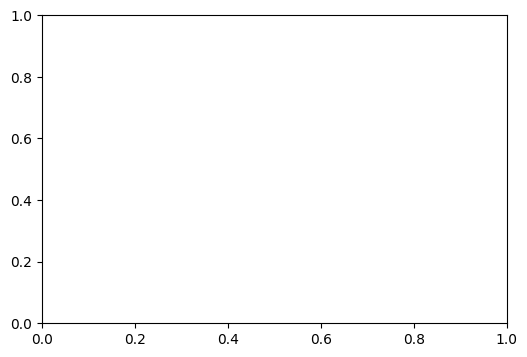

In [ ]:
fig7, ax = plt.subplots(figsize=(6, 4))

l1 = ax.plot(fig7_res["A"] * 1000, color="#00c96d", label="Modelled A")
ax.set_ylabel("Net Assimilation / $\\mu mol\\ m^{-2}\\ s^{-1}$")
ax.set_xlabel("Time / s")
ax.set_ylim(5, 20)
ax.set_yticks(np.linspace(6, 18, 5))
ax.set_xlim(0, 700)
ax.set_xticks(np.linspace(100, 600, 6))

ax2 = ax.twinx()
ax2.set_ylabel("Y(II)")
l2 = ax2.plot(fig7_res["PhiPSII"], color="#868686", ls="dotted", lw=2, label="Modelled Y(II)")
ax2.set_ylim(0, 0.8)
ax2.set_yticks(np.linspace(0.1, 0.7, 4))

ax.legend(l1 + l2, [l.get_label() for l in l1 + l2], loc="lower right", frameon=False)

patch_height = 1

p1 = ax.add_patch(
    Rectangle(
        xy=(0, ax.get_ylim()[1] - patch_height),
        width=250,
        height=patch_height,
        facecolor="#fd8040",
    )
)

p2 = ax.add_patch(
    Rectangle(
        xy=(250, ax.get_ylim()[1] - patch_height),
        width=ax.get_xlim()[1] - 250,
        height=patch_height,
        facecolor="#0000fe",
    )
)

for p in [p1, p2]:
    if p.get_x() == 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            p.get_y() + patch_height / 2,
            "Ambient O$_2$",
            color="white",
            fontsize=10,
            ha="center",
            va="center"
        )
    else:
        ax.text(
            p.get_x() + p.get_width() / 2,
            p.get_y() + patch_height / 2,
            "2% O$_2$",
            color="white",
            fontsize=10,
            ha="center",
            va="center"
        )